In [1]:
%config InlineBackend.figure_formats = ['jpeg']

import sys
sys.path.insert(0, "../src")

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import SimpleITK as sitk
from tqdm.auto import tqdm

from generate_cases import *
from seg_metrics import compute_segmentation_metrics

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.figsize": (6.5, 4.5),   # letter-paper single column width
    "figure.dpi": 72,
    "axes.prop_cycle": plt.cycler(color=["black", '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']),
    "axes.spines.top": False,
    "axes.spines.right": False,
})


In [2]:



# Collect all the data metadata
csv_path = Path("../data/raw/zenodo/picai/record-6624726/images_nii.csv")
picai_cases = pd.read_csv(csv_path)
# Convert all path to absolute paths
for col in picai_cases.columns[2:]:
    picai_cases[col] = picai_cases[col].apply(lambda x: str((csv_path.parent / x).resolve()))
# Concatenate locally run predictions

# The files are in paths like: results/picai_pred_monai_prostate/images_nii/10000/10000_1000000_t2w/10000_1000000_t2w_trans.nii.gz
picai_cases["Prostate158_adams22"] = picai_cases["ID"].apply(lambda id: f"../results/picai_pred_monai_prostate/images_nii/{id.split("_")[0]}/{id}_t2w/{id}_t2w_trans.nii.gz")
assert all(Path(p).exists() for p in picai_cases["Prostate158_adams22"]), "Some predictions are missing!"

picai_cases["Prostate158_nnunet"] = picai_cases["ID"].apply(lambda id: f"../results/picai_pred_prostate158_3d_fullres/{id}.nii.gz")
assert all(Path(p).exists() for p in picai_cases["Prostate158_nnunet"]), "Some predictions are missing!"

picai_cases["PROMISE12_nnunet"] = picai_cases["ID"].apply(lambda id: f"../results/picai_pred_promise12_3d_fullres/{id}.nii.gz")
assert all(Path(p).exists() for p in picai_cases["PROMISE12_nnunet"]), "Some predictions are missing!"

picai_cases

,ID,t2,whole_gland_ai_bosma22b,whole_gland_ai_guerbet23,zonal_pz_tz_ai_heviai23,zonal_pz_tz_ai_yuan23,Prostate158_adams22,Prostate158_nnunet,PROMISE12_nnunet
0,10000_1000000,images_nii/10000/10000_1000000_t2w.nii.gz,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,../results/picai_pred_monai_prostate/images_ni...,../results/picai_pred_prostate158_3d_fullres/1...,../results/picai_pred_promise12_3d_fullres/100...
1,10001_1000001,images_nii/10001/10001_1000001_t2w.nii.gz,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,../results/picai_pred_monai_prostate/images_ni...,../results/picai_pred_prostate158_3d_fullres/1...,../results/picai_pred_promise12_3d_fullres/100...
2,10002_1000002,images_nii/10002/10002_1000002_t2w.nii.gz,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,../results/picai_pred_monai_prostate/images_ni...,../results/picai_pred_prostate158_3d_fullres/1...,../results/picai_pred_promise12_3d_fullres/100...
3,10003_1000003,images_nii/10003/10003_1000003_t2w.nii.gz,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,../results/picai_pred_monai_prostate/images_ni...,../results/picai_pred_prostate158_3d_fullres/1...,../results/picai_pred_promise12_3d_fullres/100...
4,10004_1000004,images_nii/10004/10004_1000004_t2w.nii.gz,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,../results/picai_pred_monai_prostate/images_ni...,../results/picai_pred_prostate158_3d_fullres/1...,../results/picai_pred_promise12_3d_fullres/100...
...,...,...,...,...,...,...,...,...,...
1495,11471_1001495,images_nii/11471/11471_1001495_t2w.nii.gz,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,../results/picai_pred_monai_prostate/images_ni...,../results/picai_pred_prostate158_3d_fullres/1...,../results/picai_pred_promise12_3d_fullres/114...
1496,11472_1001496,images_nii/11472/11472_1001496_t2w.nii.gz,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,../results/picai_pred_monai_prostate/images_ni...,../results/picai_pred_prostate158_3d_fullres/1...,../results/picai_pred_promise12_3d_fullres/114...
1497,11473_1001497,images_nii/11473/11473_1001497_t2w.nii.gz,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,../results/picai_pred_monai_prostate/images_ni...,../results/picai_pred_prostate158_3d_fullres/1...,../results/picai_pred_promise12_3d_fullres/114...
1498,11474_1001498,images_nii/11474/11474_1001498_t2w.nii.gz,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,/home/bshi/Documents/prostate_train/data/raw/z...,../results/picai_pred_monai_prostate/images_ni...,../results/picai_pred_prostate158_3d_fullres/1...,../results/picai_pred_promise12_3d_fullres/114...


In [3]:
from concurrent.futures import ProcessPoolExecutor
import os

def _row_volumes(row):
    import nibabel as nib
    import numpy as np
    for col, path in row.items():
        if col in ("ID", "t2"):
            continue
        img = nib.load(path)
        data = np.asarray(img.dataobj)
        voxel_vol_mm3 = np.prod(img.header.get_zooms()[:3])
        row[col] = (data > 0).sum() * voxel_vol_mm3 / 1000.0
    return row

rows = picai_cases.to_dict("records")

with ProcessPoolExecutor(os.cpu_count() - 1) as pool:
    results = list(tqdm(pool.map(_row_volumes, rows), total=len(rows)))

volumes = pd.DataFrame(results)


# if "gt" not in volumes.columns:
    # volumes.insert(2, "gt", volumes[['whole_gland_ai_bosma22b', 'whole_gland_ai_guerbet23', 'zonal_pz_tz_ai_heviai23', 'zonal_pz_tz_ai_yuan23']].median(axis=1))
volumes["gt"] = volumes[['whole_gland_ai_bosma22b', 'whole_gland_ai_guerbet23', 'zonal_pz_tz_ai_heviai23', 'zonal_pz_tz_ai_yuan23']].median(axis=1)


volumes


  0%|          | 0/1500 [00:00<?, ?it/s]

,ID,t2,whole_gland_ai_bosma22b,whole_gland_ai_guerbet23,zonal_pz_tz_ai_heviai23,zonal_pz_tz_ai_yuan23,Prostate158_adams22,Prostate158_nnunet,PROMISE12_nnunet,gt
0,10000_1000000,images_nii/10000/10000_1000000_t2w.nii.gz,35.708303,35.502607,35.626338,37.591149,39.163103,33.615845,43.323742,35.667320
1,10001_1000001,images_nii/10001/10001_1000001_t2w.nii.gz,89.674461,88.484732,92.784213,93.510945,98.505729,86.998868,95.572557,91.229337
2,10002_1000002,images_nii/10002/10002_1000002_t2w.nii.gz,68.688750,70.541250,74.671500,73.729500,73.197744,67.087500,65.831250,72.135375
3,10003_1000003,images_nii/10003/10003_1000003_t2w.nii.gz,72.416250,72.231000,74.361000,73.858500,77.959506,69.359250,76.050000,73.137375
4,10004_1000004,images_nii/10004/10004_1000004_t2w.nii.gz,60.776244,61.174764,61.069140,64.428048,67.939890,59.685012,64.924092,61.121952
...,...,...,...,...,...,...,...,...,...,...
1495,11471_1001495,images_nii/11471/11471_1001495_t2w.nii.gz,51.678375,52.892000,51.163000,51.168250,52.404629,46.624375,52.391500,51.423313
1496,11472_1001496,images_nii/11472/11472_1001496_t2w.nii.gz,34.839720,35.065224,36.317160,39.699396,70.644306,31.160376,44.482932,35.691192
1497,11473_1001497,images_nii/11473/11473_1001497_t2w.nii.gz,71.053200,71.361972,73.283292,74.853072,79.467149,72.360540,80.999676,72.322632
1498,11474_1001498,images_nii/11474/11474_1001498_t2w.nii.gz,74.302031,75.453750,78.582656,76.545000,83.408899,73.213594,87.537656,75.999375


In [4]:
# from concurrent.futures import ProcessPoolExecutor
# from pathlib import Path
# import os

# def _load_lesion_vol(path):
#     import nibabel as nib
#     import numpy as np
#     img = nib.load(path)
#     vox_vol = np.prod(img.header.get_zooms()[:3]) / 1000
#     vol = float((np.asarray(img.dataobj) > 0).sum() * vox_vol)
#     case_id = Path(path).name.removesuffix(".nii.gz")
#     return case_id, vol

# base = Path("../data/raw/zenodo/picai/picai_labels/csPCa_lesion_delineations/human_expert")
# labels = list((base / "resampled").glob("*.nii.gz"))
# labels += list((base / "Pooch25").glob("*.nii.gz"))

# with ProcessPoolExecutor(os.cpu_count() - 1) as pool:
#     results = list(tqdm(pool.map(_load_lesion_vol, labels), total=len(labels)))

# volumes["lesion_volume"] = volumes["ID"].map(dict(results))

In [5]:
marksheet = pd.read_csv("../data/raw/zenodo/picai/picai_labels/clinical_information/marksheet.csv")

if "patient_id" not in volumes.columns:
    volumes = pd.concat([volumes, marksheet], axis=1)
assert (volumes["ID"] == volumes["patient_id"].astype(str) + "_" + volumes["study_id"].astype(str)).all(), "IDs do not match."


In [6]:
volumes["psa/psad"] = volumes["psa"] / volumes["psad"]
volumes

,ID,t2,whole_gland_ai_bosma22b,whole_gland_ai_guerbet23,zonal_pz_tz_ai_heviai23,zonal_pz_tz_ai_yuan23,Prostate158_adams22,Prostate158_nnunet,PROMISE12_nnunet,gt,...,psa,psad,prostate_volume,histopath_type,lesion_GS,lesion_ISUP,case_ISUP,case_csPCa,center,psa/psad
0,10000_1000000,images_nii/10000/10000_1000000_t2w.nii.gz,35.708303,35.502607,35.626338,37.591149,39.163103,33.615845,43.323742,35.667320,...,7.70,NaN,55.0,MRBx,0+0,0,0,NO,PCNN,NaN
1,10001_1000001,images_nii/10001/10001_1000001_t2w.nii.gz,89.674461,88.484732,92.784213,93.510945,98.505729,86.998868,95.572557,91.229337,...,8.70,0.09,102.0,NaN,NaN,NaN,0,NO,RUMC,96.666667
2,10002_1000002,images_nii/10002/10002_1000002_t2w.nii.gz,68.688750,70.541250,74.671500,73.729500,73.197744,67.087500,65.831250,72.135375,...,4.20,0.06,74.0,NaN,NaN,NaN,0,NO,ZGT,70.000000
3,10003_1000003,images_nii/10003/10003_1000003_t2w.nii.gz,72.416250,72.231000,74.361000,73.858500,77.959506,69.359250,76.050000,73.137375,...,13.00,NaN,71.5,SysBx,0+0,0,0,NO,ZGT,NaN
4,10004_1000004,images_nii/10004/10004_1000004_t2w.nii.gz,60.776244,61.174764,61.069140,64.428048,67.939890,59.685012,64.924092,61.121952,...,8.00,0.10,78.0,SysBx+MRBx,"0+0,0+0","0,0",0,NO,RUMC,80.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,11471_1001495,images_nii/11471/11471_1001495_t2w.nii.gz,51.678375,52.892000,51.163000,51.168250,52.404629,46.624375,52.391500,51.423313,...,12.50,0.21,62.0,MRBx,"3+4,N/A,3+3","2,1",2,YES,RUMC,59.523810
1496,11472_1001496,images_nii/11472/11472_1001496_t2w.nii.gz,34.839720,35.065224,36.317160,39.699396,70.644306,31.160376,44.482932,35.691192,...,5.28,0.12,44.0,SysBx+MRBx,3+4,2,2,YES,RUMC,44.000000
1497,11473_1001497,images_nii/11473/11473_1001497_t2w.nii.gz,71.053200,71.361972,73.283292,74.853072,79.467149,72.360540,80.999676,72.322632,...,29.60,0.34,87.0,MRBx,0+0,0,0,NO,RUMC,87.058824
1498,11474_1001498,images_nii/11474/11474_1001498_t2w.nii.gz,74.302031,75.453750,78.582656,76.545000,83.408899,73.213594,87.537656,75.999375,...,12.00,NaN,83.0,MRBx,3+3,1,1,NO,PCNN,NaN


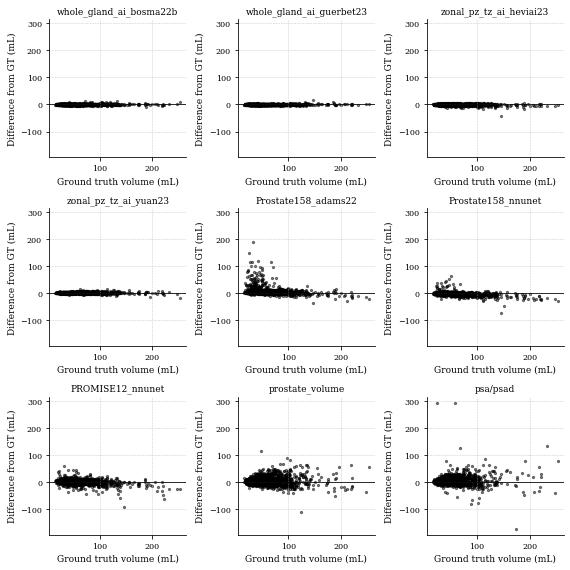

In [7]:
import matplotlib.pyplot as plt

methods = [
    "whole_gland_ai_bosma22b",
    "whole_gland_ai_guerbet23",
    "zonal_pz_tz_ai_heviai23",
    "zonal_pz_tz_ai_yuan23",
    "Prostate158_adams22",
    "Prostate158_nnunet",
    "PROMISE12_nnunet",
    "prostate_volume",
    "psa/psad"
]

ncols = 3
nrows = -(-len(methods) // ncols)  # ceiling division
fig, axes = plt.subplots(nrows, ncols, figsize=(8, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, method in zip(axes, methods):
    diff = volumes[method] - volumes["gt"]
    ax.scatter(volumes["gt"], diff, s=5, alpha=0.5)
    ax.axhline(0, color="k", linewidth=0.8)
    ax.set_title(method, fontsize=9)
    ax.set_xlabel("Ground truth volume (mL)")
    ax.set_ylabel("Difference from GT (mL)")

for ax in fig.axes:
    ax.tick_params(labelleft=True, labelbottom=True)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

for ax in axes[len(methods):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


In [8]:
stats = {}
for method in methods:
    diff = volumes[method] - volumes["gt"]
    stats[method] = diff.describe()

pd.DataFrame(stats).T.style.format(precision=1)


,count,mean,std,min,25%,50%,75%,max
whole_gland_ai_bosma22b,1500.0,-0.4,1.7,-9.2,-1.2,-0.3,0.2,14.4
whole_gland_ai_guerbet23,1500.0,-0.5,1.4,-6.2,-1.2,-0.4,0.1,16.2
zonal_pz_tz_ai_heviai23,1500.0,-0.2,2.7,-43.3,-1.1,0.3,1.2,6.9
zonal_pz_tz_ai_yuan23,1500.0,1.7,2.5,-17.6,0.2,1.5,3.0,14.4
Prostate158_adams22,1500.0,7.0,14.8,-36.6,1.4,4.0,7.7,188.2
Prostate158_nnunet,1500.0,-2.4,6.7,-73.0,-4.9,-2.2,0.0,64.1
PROMISE12_nnunet,1500.0,1.0,9.2,-93.0,-2.4,1.9,5.5,58.2
prostate_volume,1473.0,5.1,15.4,-112.0,-4.0,3.6,12.4,112.9
psa/psad,1042.0,6.3,21.5,-171.9,-3.3,4.5,13.7,291.2


In [9]:
import pingouin as pg
from itertools import combinations

n = len(methods)
icc_vals = pd.DataFrame(np.ones((n, n)), index=methods, columns=methods)
icc_ci  = pd.DataFrame("", index=methods, columns=methods)

for m1, m2 in combinations(methods, 2):
    long = pd.concat([
        volumes[["ID", m1]].rename(columns={m1: "volume"}).assign(rater=m1),
        volumes[["ID", m2]].rename(columns={m2: "volume"}).assign(rater=m2),
    ]).dropna(subset=["volume"])

    res = pg.intraclass_corr(data=long, targets="ID", raters="rater", ratings="volume", nan_policy='omit')
    row = res.set_index("Type").loc["ICC(A,1)"]   # two-way mixed, absolute agreement
    icc  = row["ICC"]
    lo, hi = row["CI95"]

    icc_vals.loc[m1, m2] = icc
    icc_vals.loc[m2, m1] = icc
    icc_ci.loc[m1, m2] = f"{icc:.3f} [{lo:.3f}, {hi:.3f}]"
    icc_ci.loc[m2, m1] = icc_ci.loc[m1, m2]

# np.fill_diagonal(icc_ci.values, "1.000")

print("ICC(A,1) — two-way mixed, absolute agreement\n")
icc_vals.style.background_gradient(cmap="RdYlGn", vmin=0, vmax=1).format(precision=3)

ICC(A,1) — two-way mixed, absolute agreement



,whole_gland_ai_bosma22b,whole_gland_ai_guerbet23,zonal_pz_tz_ai_heviai23,zonal_pz_tz_ai_yuan23,Prostate158_adams22,Prostate158_nnunet,PROMISE12_nnunet,prostate_volume,psa/psad
whole_gland_ai_bosma22b,1.000,0.999,0.993,0.992,0.875,0.972,0.955,0.887,0.818
whole_gland_ai_guerbet23,0.999,1.000,0.994,0.992,0.875,0.973,0.955,0.887,0.817
zonal_pz_tz_ai_heviai23,0.993,0.994,1.000,0.993,0.882,0.979,0.961,0.894,0.823
zonal_pz_tz_ai_yuan23,0.992,0.992,0.993,1.000,0.889,0.969,0.957,0.898,0.828
Prostate158_adams22,0.875,0.875,0.882,0.889,1.000,0.863,0.845,0.826,0.824
Prostate158_nnunet,0.972,0.973,0.979,0.969,0.863,1.000,0.952,0.866,0.800
PROMISE12_nnunet,0.955,0.955,0.961,0.957,0.845,0.952,1.000,0.863,0.808
prostate_volume,0.887,0.887,0.894,0.898,0.826,0.866,0.863,1.000,0.900
psa/psad,0.818,0.817,0.823,0.828,0.824,0.800,0.808,0.900,1.000


In [10]:
methods = [
    # "gt",
    "whole_gland_ai_bosma22b",
    "whole_gland_ai_guerbet23",
    "zonal_pz_tz_ai_heviai23",
    "zonal_pz_tz_ai_yuan23",
    "Prostate158_adams22",
    "Prostate158_nnunet",
    "PROMISE12_nnunet",
    "prostate_volume",
    # "psa/psad"
]

psad = volumes.copy()
for method in methods:
    psad[method] = psad["psa"] / volumes[method]
psad["gt"] = psad["psa"] / volumes["gt"]
psad

,ID,t2,whole_gland_ai_bosma22b,whole_gland_ai_guerbet23,zonal_pz_tz_ai_heviai23,zonal_pz_tz_ai_yuan23,Prostate158_adams22,Prostate158_nnunet,PROMISE12_nnunet,gt,...,psa,psad,prostate_volume,histopath_type,lesion_GS,lesion_ISUP,case_ISUP,case_csPCa,center,psa/psad
0,10000_1000000,images_nii/10000/10000_1000000_t2w.nii.gz,0.215636,0.216885,0.216132,0.204835,0.196614,0.229059,0.177732,0.215884,...,7.70,NaN,0.140000,MRBx,0+0,0,0,NO,PCNN,NaN
1,10001_1000001,images_nii/10001/10001_1000001_t2w.nii.gz,0.097018,0.098322,0.093766,0.093037,0.088320,0.100001,0.091030,0.095364,...,8.70,0.09,0.085294,NaN,NaN,NaN,0,NO,RUMC,96.666667
2,10002_1000002,images_nii/10002/10002_1000002_t2w.nii.gz,0.061145,0.059540,0.056246,0.056965,0.057379,0.062605,0.063799,0.058224,...,4.20,0.06,0.056757,NaN,NaN,NaN,0,NO,ZGT,70.000000
3,10003_1000003,images_nii/10003/10003_1000003_t2w.nii.gz,0.179518,0.179978,0.174823,0.176012,0.166753,0.187430,0.170940,0.177748,...,13.00,NaN,0.181818,SysBx,0+0,0,0,NO,ZGT,NaN
4,10004_1000004,images_nii/10004/10004_1000004_t2w.nii.gz,0.131630,0.130773,0.130999,0.124170,0.117751,0.134037,0.123221,0.130886,...,8.00,0.10,0.102564,SysBx+MRBx,"0+0,0+0","0,0",0,NO,RUMC,80.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,11471_1001495,images_nii/11471/11471_1001495_t2w.nii.gz,0.241881,0.236331,0.244317,0.244292,0.238529,0.268100,0.238588,0.243080,...,12.50,0.21,0.201613,MRBx,"3+4,N/A,3+3","2,1",2,YES,RUMC,59.523810
1496,11472_1001496,images_nii/11472/11472_1001496_t2w.nii.gz,0.151551,0.150577,0.145386,0.133000,0.074741,0.169446,0.118697,0.147936,...,5.28,0.12,0.120000,SysBx+MRBx,3+4,2,2,YES,RUMC,44.000000
1497,11473_1001497,images_nii/11473/11473_1001497_t2w.nii.gz,0.416589,0.414787,0.403912,0.395441,0.372481,0.409063,0.365434,0.409277,...,29.60,0.34,0.340230,MRBx,0+0,0,0,NO,RUMC,87.058824
1498,11474_1001498,images_nii/11474/11474_1001498_t2w.nii.gz,0.161503,0.159038,0.152705,0.156771,0.143870,0.163904,0.137084,0.157896,...,12.00,NaN,0.144578,MRBx,3+3,1,1,NO,PCNN,NaN


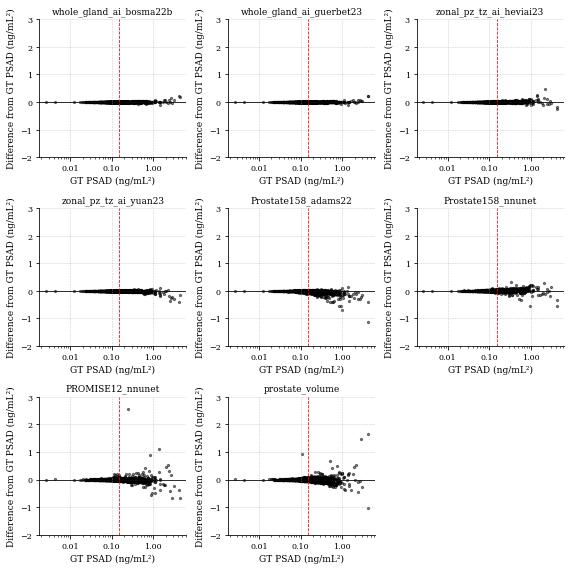

In [11]:
ncols = 3
nrows = -(-len(methods) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(8, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, method in zip(axes, methods):
#     # Filter for cases with lesion)
#     mask = psad["lesion_volume"] > 0
#     print(f"{mask.sum()} cases with lesion for method {method}")
#     print(f"Shape of GT PSAD for method {method}: {psad.loc[mask, "gt"].shape}")
#     print(f"Non-NaN values for method {method}: {psad.loc[mask, method].notna().sum()}")

    ax.scatter(psad.loc[:, "gt"], psad.loc[:, method] - psad.loc[:, "gt"], s=5, alpha=0.5)
    ax.axhline(0, color="k", linewidth=0.8)
    ax.set_title(method, fontsize=9)
    ax.set_xlabel("GT PSAD (ng/mL²)")
    ax.set_ylabel("Difference from GT PSAD (ng/mL²)")

for ax in fig.axes:
    ax.tick_params(labelleft=True, labelbottom=True)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
    ax.set_xscale("log")
    # 1. Force the use of standard decimal representation
    import matplotlib.ticker as ticker
    formatter = ticker.ScalarFormatter()
    formatter.set_powerlimits((-np.inf, np.inf)) 
    # 2. Apply it to the major ticks of your log axis
    ax.xaxis.set_major_formatter(formatter)

    # ax.set_xlim([0, 4])
    ax.set_ylim([-2, 3])
    ax.axvline(0.15, color="r", linewidth=0.8, linestyle="--")

for ax in axes[len(methods):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


In [12]:
stats = {}
for method in methods:
    diff = psad[method] - psad["gt"]
    # mask = psad["lesion_volume"] > 0
    stats[method] = diff.describe()
    print(diff.shape)

pd.DataFrame(stats).T.style.format(precision=4)

(1500,)
(1500,)
(1500,)
(1500,)
(1500,)
(1500,)
(1500,)
(1500,)


,count,mean,std,min,25%,50%,75%,max
whole_gland_ai_bosma22b,1460.0000,0.0020,0.0122,-0.0984,-0.0005,0.0009,0.0037,0.2216
whole_gland_ai_guerbet23,1460.0000,0.0022,0.0109,-0.1154,-0.0001,0.0012,0.0038,0.2024
zonal_pz_tz_ai_heviai23,1460.0000,0.0017,0.0230,-0.2457,-0.0036,-0.0007,0.0031,0.4755
zonal_pz_tz_ai_yuan23,1460.0000,-0.0079,0.0241,-0.4187,-0.0094,-0.0039,-0.0006,0.1142
Prostate158_adams22,1460.0000,-0.0269,0.0620,-1.1271,-0.0266,-0.0108,-0.0031,0.1532
Prostate158_nnunet,1460.0000,0.0093,0.0913,-0.5705,-0.0001,0.0058,0.0152,3.1154
PROMISE12_nnunet,1460.0000,-0.0015,0.1538,-0.6869,-0.0187,-0.0042,0.0058,4.5000
prostate_volume,1439.0000,-0.0034,0.1806,-1.0381,-0.0312,-0.0074,0.0115,5.8150


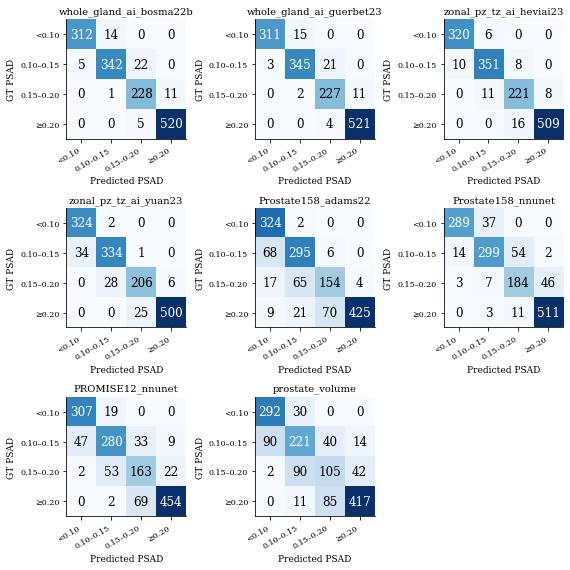

In [13]:

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cutoffs = [0.10, 0.15, 0.20]
bins = [0] + cutoffs + [np.inf]
bin_labels = ["<0.10", "0.10–0.15", "0.15–0.20", "≥0.20"]

gt_psad = psad["gt"]
gt_cat = pd.cut(gt_psad, bins=bins, labels=bin_labels, right=False)

ncols = 3
nrows = -(-len(methods) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(8, 8))
axes = axes.flatten()

for ax, method in zip(axes, methods):
    pred_psad = psad[method]
    pred_cat = pd.cut(pred_psad, bins=bins, labels=bin_labels, right=False)

    valid = gt_cat.notna() & pred_cat.notna()
    cm = confusion_matrix(gt_cat[valid], pred_cat[valid], labels=bin_labels)

    ax.imshow(cm, cmap="Blues")
    for i in range(4):
        for j in range(4):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=12,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_xticks(range(4))
    ax.set_yticks(range(4))
    ax.set_xticklabels(bin_labels, rotation=30, ha="right")
    ax.set_yticklabels(bin_labels)
    ax.set_xlabel("Predicted PSAD")
    ax.set_ylabel("GT PSAD")
    ax.set_title(method)

for ax in axes[len(methods):]:
    ax.set_visible(False)

# plt.suptitle("PSAD 4×4 Confusion Matrices (cutoffs: 0.10, 0.15, 0.20)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


whole_gland_ai_bosma22b: AUC = 0.737, PSAD cutoff at threshold=0.150, FPR=0.444, TPR=0.774
whole_gland_ai_guerbet23: AUC = 0.738, PSAD cutoff at threshold=0.150, FPR=0.441, TPR=0.774
zonal_pz_tz_ai_heviai23: AUC = 0.741, PSAD cutoff at threshold=0.150, FPR=0.425, TPR=0.767
zonal_pz_tz_ai_yuan23: AUC = 0.738, PSAD cutoff at threshold=0.151, FPR=0.407, TPR=0.748
Prostate158_adams22: AUC = 0.729, PSAD cutoff at threshold=0.150, FPR=0.346, TPR=0.707
Prostate158_nnunet: AUC = 0.738, PSAD cutoff at threshold=0.151, FPR=0.455, TPR=0.791
PROMISE12_nnunet: AUC = 0.726, PSAD cutoff at threshold=0.151, FPR=0.419, TPR=0.748
prostate_volume: AUC = 0.723, PSAD cutoff at threshold=0.150, FPR=0.396, TPR=0.723


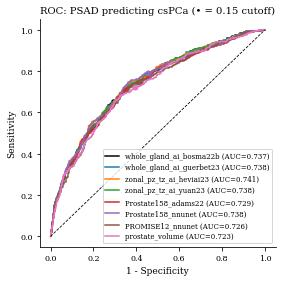

In [14]:
from sklearn.metrics import roc_curve, roc_auc_score

y_true = volumes["case_csPCa"].map({"YES": 1, "NO": 0}).dropna()
idx = y_true.index

fig, ax = plt.subplots(figsize=(4, 4))
for method in methods:
    score = (volumes.loc[idx, "psa"] / volumes.loc[idx, method]).dropna()
    valid = y_true.loc[score.index]
    fpr, tpr, thresholds = roc_curve(valid, score)
    auc = roc_auc_score(valid, score)
    (line,) = ax.plot(fpr, tpr, label=f"{method} (AUC={auc:.3f})")
    # Mark the point closest to PSAD=0.15 cutoff
    cut_idx = np.argmin(np.abs(thresholds - 0.15))
    print(f"{method}: AUC = {auc:.3f}, PSAD cutoff at threshold={thresholds[cut_idx]:.3f}, FPR={fpr[cut_idx]:.3f}, TPR={tpr[cut_idx]:.3f}")
    ax.plot(fpr[cut_idx], tpr[cut_idx], "o", color=line.get_color(), markersize=5)

ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set_xlabel("1 - Specificity")
ax.set_ylabel("Sensitivity")
ax.set_title("ROC: PSAD predicting csPCa (• = 0.15 cutoff)")
ax.legend(loc="lower right", fontsize=7)
plt.tight_layout()
plt.show()


In [15]:
# Find human errors: cases where the difference between the ground truth and the volume is large. We can look at both absolute and relative differences.
df = volumes[["ID", 'gt', "prostate_volume", 'psa/psad', 'psa', 'psad', 'whole_gland_ai_bosma22b', 'whole_gland_ai_guerbet23',
       'zonal_pz_tz_ai_heviai23', 'zonal_pz_tz_ai_yuan23',
       'Prostate158_adams22', 'Prostate158_nnunet', 'PROMISE12_nnunet']].dropna()
# df[df.eval("abs(prostate_volume - gt)").argsort()]
large_abs_diff = df.iloc[df.eval("abs(prostate_volume - gt)").argsort()[::-1]]
large_abs_diff.head()

,ID,gt,prostate_volume,psa/psad,psa,psad,whole_gland_ai_bosma22b,whole_gland_ai_guerbet23,zonal_pz_tz_ai_heviai23,zonal_pz_tz_ai_yuan23,Prostate158_adams22,Prostate158_nnunet,PROMISE12_nnunet
1315,11292_1001315,124.978500,13.0,112.500000,13.50,0.12,123.588750,124.506750,125.450250,136.308750,128.612250,117.651000,124.378500
1272,11249_1001272,102.758058,184.0,44.000000,0.44,0.01,103.145400,102.370716,100.581264,110.214108,110.959977,96.505992,86.750676
888,10872_1000888,83.533875,148.0,144.545455,15.90,0.11,83.135250,83.932500,86.472750,82.966500,92.268000,87.019500,93.318000
183,10180_1000183,133.534125,196.0,187.500000,15.00,0.08,147.951000,140.184000,125.139750,126.884250,132.422250,123.233250,121.657500
643,10629_1000643,122.110578,183.0,183.333333,11.00,0.06,119.997612,117.756504,124.223544,125.828964,130.189020,124.345692,120.756096


In [16]:
large_rel_diff = df.iloc[df.eval("abs(log(prostate_volume) - log(gt))").argsort()[::-1]]
large_rel_diff.head()

,ID,gt,prostate_volume,psa/psad,psa,psad,whole_gland_ai_bosma22b,whole_gland_ai_guerbet23,zonal_pz_tz_ai_heviai23,zonal_pz_tz_ai_yuan23,Prostate158_adams22,Prostate158_nnunet,PROMISE12_nnunet
1315,11292_1001315,124.978500,13.0,112.500000,13.50,0.12,123.588750,124.506750,125.450250,136.308750,128.612250,117.651000,124.378500
783,10767_1000783,44.549028,90.0,90.000000,9.90,0.11,42.794244,43.011972,46.086084,46.571760,52.385616,45.178560,51.858144
441,10433_1000441,25.639416,13.0,13.142857,4.60,0.35,25.431732,25.306344,25.847100,33.447492,27.148284,17.959968,28.625724
1174,11151_1001174,52.299486,101.0,100.000000,12.00,0.12,51.684962,51.949225,52.649748,56.417767,64.777347,53.412920,77.211353
1436,11412_1001436,16.007544,30.0,19.666667,0.59,0.03,15.142140,14.936724,17.596764,16.872948,18.802692,17.659944,20.949840
